In [11]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

from utils.models import CNNLSTM
from utils.preprocessing import FEATURES, normalize_label_name, preprocess_data
from utils.evaluation import (
    evaluate_model,
    load_and_evaluate_rf_model,
    load_and_evaluate_cnnlstm_model,
)
from utils.experiment_logger import save_cross_dataset_evaluation
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Preprocess data

In [12]:
df_cicids2017 = preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [13]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
df_ciciot2023 = df_ciciot2023[df_ciciot2023["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]

X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 7)
CICIoT test shape: (1850844, 7)


## Load Models

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_2644\1603510616.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test.select_dtypes(include=["object"]).columns



CICIDS2017-trained RF model tested on CICIoT2023
Accuracy: 0.2291

=== CICIDS2017-trained RF on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1930    0.9962    0.3234    342255
DOS_HTTP_FLOOD     0.9845    0.0551    0.1044   1508589

      accuracy                         0.2291   1850844
     macro avg     0.5887    0.5256    0.2139   1850844
  weighted avg     0.8381    0.2291    0.1449   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9962
DOS_HTTP_FLOOD: 0.0551


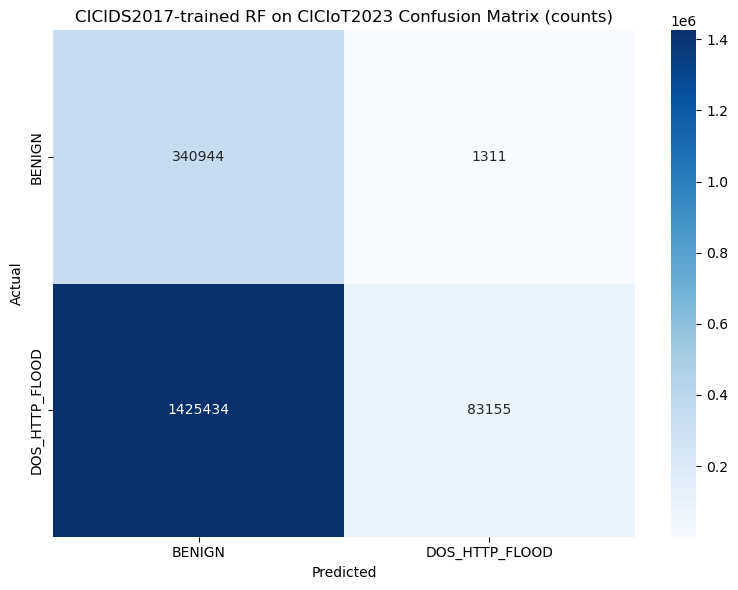

{'BENIGN': {'precision': 0.19301870833989102,
  'recall': 0.9961695227242845,
  'f1-score': 0.32337917503899444,
  'support': 342255.0},
 'DOS_HTTP_FLOOD': {'precision': 0.9844789619491866,
  'recall': 0.0551210435711781,
  'f1-score': 0.10439689778444561,
  'support': 1508589.0},
 'accuracy': 0.2291381661555485,
 'macro avg': {'precision': 0.5887488351445388,
  'recall': 0.5256452831477313,
  'f1-score': 0.21388803641172002,
  'support': 1850844.0},
 'weighted avg': {'precision': 0.8381234457095417,
  'recall': 0.2291381661555485,
  'f1-score': 0.1448907369744344,
  'support': 1850844.0}}

In [14]:
# Test CICIDS2017-trained RF model on CICIoT2023
joblib_object = joblib.load("models/random_forest_cicids2017.joblib")
experiment_folder = joblib_object.get("experiment_folder")
model = joblib_object["model"]
encoder = joblib_object.get("encoder")

X_test = X_ciciot.copy()
categorical_cols = X_test.select_dtypes(include=["object"]).columns
if encoder is not None and len(categorical_cols) > 0:
    X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_ciciot.values)
cm = confusion_matrix(y_ciciot.astype(str), y_pred.astype(str))
class_report = classification_report(y_ciciot.astype(str), y_pred.astype(str), output_dict=True, zero_division=0)

print(f"\nCICIDS2017-trained RF model tested on CICIoT2023")
print(f"Accuracy: {accuracy:.4f}")
evaluate_model(y_ciciot, y_pred, "CICIDS2017-trained RF on CICIoT2023")

In [15]:
# Save results to experiment folder
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder,
    tested_on="ciciot2023",
    accuracy=float(accuracy),
    classification_report=class_report,
    confusion_matrix=cm,
    experiments_dir="../baseline/experiments"
)
print(f"Saved cross-eval results to experiment: {experiment_folder}")

Cross-dataset evaluation saved to: ..\baseline\experiments\20260406_120413_0props\cross_eval_on_ciciot2023.json
Saved cross-eval results to experiment: 20260406_120413_0props


C:\Users\Rasmus\AppData\Local\Temp\ipykernel_2644\1555385033.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test.select_dtypes(include=["object"]).columns



CICIoT2023-trained RF model tested on CICIDS2017
Accuracy: 0.8271

=== CICIoT2023-trained RF on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8391    0.9221    0.8786    327060
DOS_HTTP_FLOOD     0.7918    0.6263    0.6994    154769

      accuracy                         0.8271    481829
     macro avg     0.8155    0.7742    0.7890    481829
  weighted avg     0.8239    0.8271    0.8211    481829


=== Per-Label Accuracy ===

BENIGN: 0.9221
DOS_HTTP_FLOOD: 0.6263


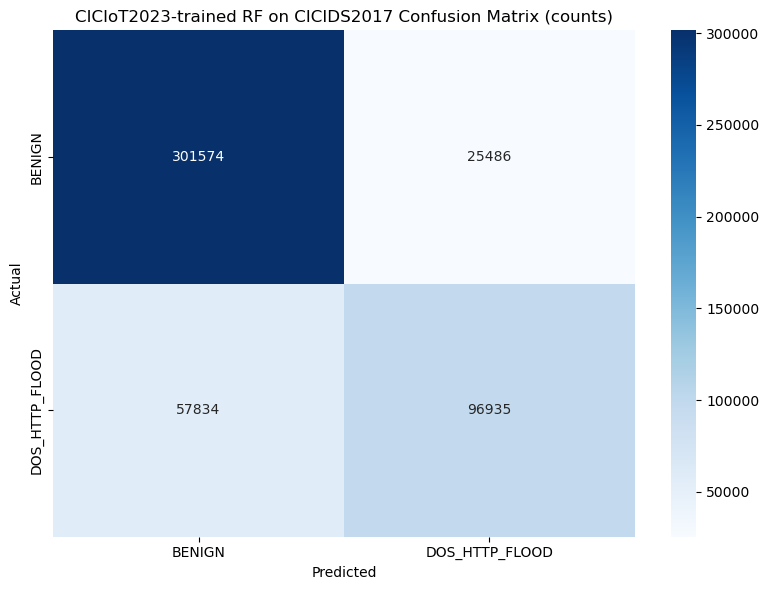

Cross-dataset evaluation saved to: ..\baseline\experiments\20260406_120156_0props\cross_eval_on_cicids2017.json
Saved cross-eval results to experiment: 20260406_120156_0props


In [16]:
# Test CICIoT2023-trained RF model on CICIDS2017
joblib_object = joblib.load("models/random_forest_ciciot2023.joblib")
experiment_folder = joblib_object.get("experiment_folder")
model = joblib_object["model"]
encoder = joblib_object.get("encoder")

X_test = X_cicids.copy()
categorical_cols = X_test.select_dtypes(include=["object"]).columns
if encoder is not None and len(categorical_cols) > 0:
    X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_cicids.values)
cm = confusion_matrix(y_cicids.astype(str), y_pred.astype(str))
class_report = classification_report(y_cicids.astype(str), y_pred.astype(str), output_dict=True, zero_division=0)

print(f"\nCICIoT2023-trained RF model tested on CICIDS2017")
print(f"Accuracy: {accuracy:.4f}")
evaluate_model(y_cicids, y_pred, "CICIoT2023-trained RF on CICIDS2017")

# Save results to experiment folder
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder,
    tested_on="cicids2017",
    accuracy=float(accuracy),
    classification_report=class_report,
    confusion_matrix=cm,
    experiments_dir="../baseline/experiments"
)
print(f"Saved cross-eval results to experiment: {experiment_folder}")

Evaluation for CICIoT2023-trained CNN-LSTM on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.6811    0.9663    0.7990    327060
DOS_HTTP_FLOOD     0.3824    0.0441    0.0791    154769

      accuracy                         0.6701    481829
     macro avg     0.5317    0.5052    0.4391    481829
  weighted avg     0.5852    0.6701    0.5678    481829


=== Per-Label Accuracy ===

BENIGN: 0.9663
DOS_HTTP_FLOOD: 0.0441


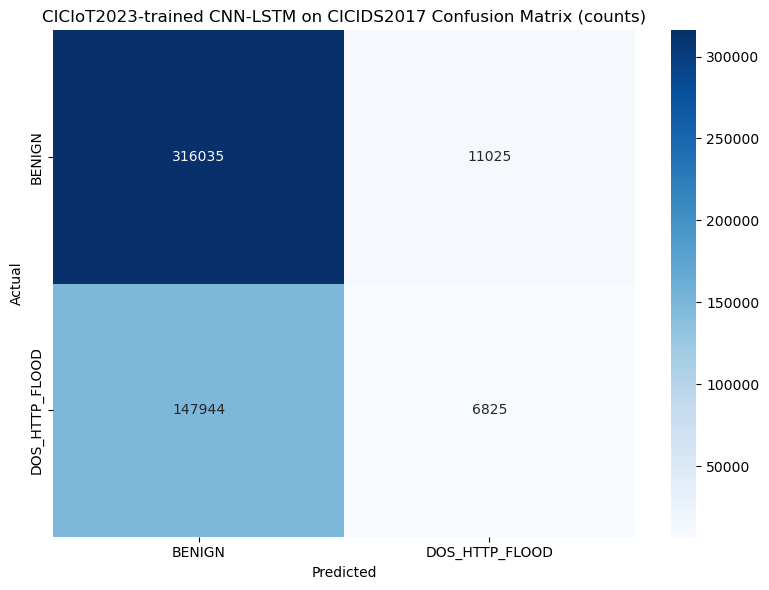

Cross-dataset evaluation saved to: ..\baseline\experiments\20260406_120348_0props\cross_eval_on_cicids2017.json
Saved cross-eval results to experiment: 20260406_120348_0props


In [18]:
# Test CICIoT2023-trained CNN-LSTM model on CICIDS2017
joblib_object = joblib.load("models/cnnlstm_ciciot2023.joblib")
experiment_folder = joblib_object.get("experiment_folder")
results = load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM on CICIDS2017"
)

# Save results to experiment folder
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder,
    tested_on="cicids2017",
    accuracy=results["accuracy"],
    classification_report=results["classification_report"],
    confusion_matrix=results["confusion_matrix"],
    experiments_dir="../baseline/experiments"
)
print(f"Saved cross-eval results to experiment: {experiment_folder}")

Evaluation for CICIDS2017-trained CNN-LSTM on CICIoT2023:

=== CICIDS2017-trained CNN-LSTM on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2015    0.9698    0.3337    342255
DOS_HTTP_FLOOD     0.9492    0.1283    0.2260   1508589

      accuracy                         0.2839   1850844
     macro avg     0.5754    0.5490    0.2798   1850844
  weighted avg     0.8110    0.2839    0.2459   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9698
DOS_HTTP_FLOOD: 0.1283


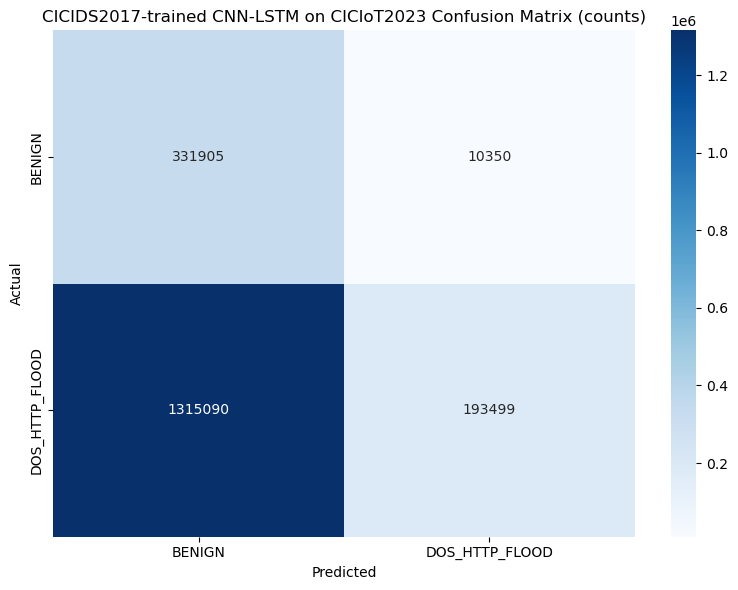

Cross-dataset evaluation saved to: ..\baseline\experiments\20260406_120500_0props\cross_eval_on_ciciot2023.json
Saved cross-eval results to experiment: 20260406_120500_0props


In [19]:
# Test CICIDS2017-trained CNN-LSTM model on CICIoT2023
joblib_object = joblib.load("models/cnnlstm_cicids2017.joblib")
experiment_folder = joblib_object.get("experiment_folder")
results = load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM on CICIoT2023"
)

# Save results to experiment folder
save_cross_dataset_evaluation(
    experiment_folder=experiment_folder,
    tested_on="ciciot2023",
    accuracy=results["accuracy"],
    classification_report=results["classification_report"],
    confusion_matrix=results["confusion_matrix"],
    experiments_dir="../baseline/experiments"
)
print(f"Saved cross-eval results to experiment: {experiment_folder}")